# Домашнее задание 1: Анализ метагеномных данных (16S rRNA)

**Бганцова  Полина Анатольевна, Б06-304в**


23.09.2026


## 1  Цель
Проанализировать данные микробиоты мышей (mice) и почвы (soil).  
Сравнить таксономический состав и разнообразие между группами.

## 2 Данные
- **Mice:** 29 образцов (L1–L8, LR1–LR7, W1–W7, WR1–WR7), paired-end 2×250 bp, регион V4.
- **Soil:** 36 образцов, single-end 250 bp, регион V4–V5.
- Данные предоставлены в виде FASTQ-файлов на сервере.

## 3 Форматы файлов

| Формат | Что хранит | Text/Binary | Для чего использовали |
|--------|------------|-------------|----------------------|
| FASTA | Нуклеотидные/белковые последовательности | Text | Референсный геном, ASV |
| GTF | Аннотация генома | Text | Аннотация для IGV |
| BAM | Выравнивания прочтений | Binary | Входные данные для DADA2 |
| BAI | Индекс BAM | Binary | Ускорение доступа |
| BigWig | Непрерывный сигнал | Binary | Визуализация coverage |
| BED | Геномные интервалы | Text | Пики, регионы |
| narrowPeak | Пики ChIP-seq | Text | Результаты MACS3 |
| qza | Артефакт QIIME2 | Binary | Промежуточные файлы |
| qzv | Визуализация QIIME2 | Binary | Результаты для просмотра |
| TSV | Табличные данные | Text | Метаданные |
| matrix.gz | Матрица для heatmap | Binary | deepTools |
| PDF | Отчёт | Binary | Итоговый документ |

### 4.1 Контроль качества (FastQC) — Mice
- Длина ридов: 250 bp  
- Всего последовательностей: 2138  
- GC: 53%  
- Плохих прочтений: 0  


-> Качество хорошее, адаптеров нет.



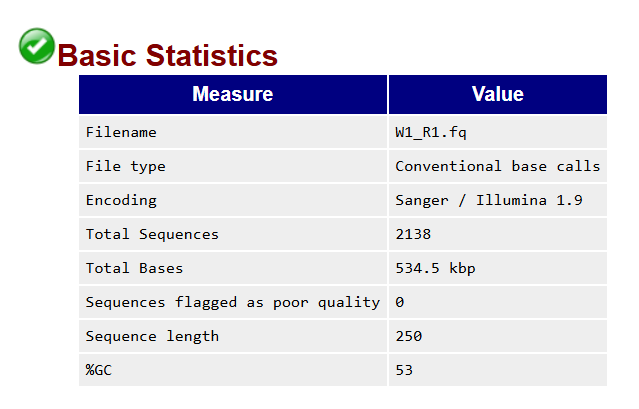

### Контроль качества (FastQC) — Soil

- Длина ридов: 251 bp
- Всего последовательностей: 10833
- GC: 57%
- Плохих прочтений: 0


-> Качество хорошее, адаптеров нет.

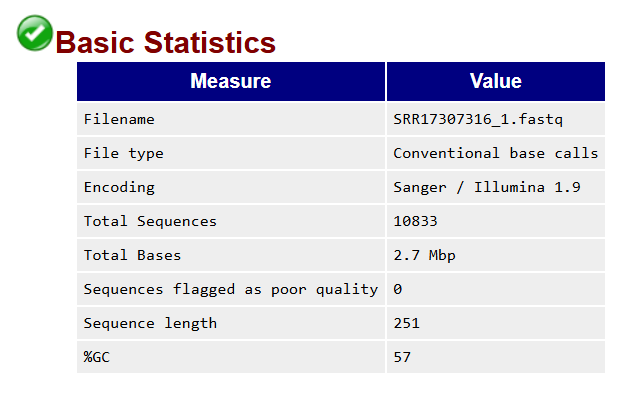

### 4.2. DADA2 stats — Soil

- Всего образцов: 36.
- Доля выживших прочтений (non-chimeric от input) варьирует от **89.4%** (SRR17307273) до **97.08%** (SRR17307419).
- Самый большой образец: **SRR17307475** (45492 → 43518).
- Самый маленький образец: **SRR17307380** (5128 → 4809).

 **->** Данные высокого качества. Потери на всех стадиях минимальны (в среднем ~5%), что говорит о хорошем качестве секвенирования и успешной работе DADA2.

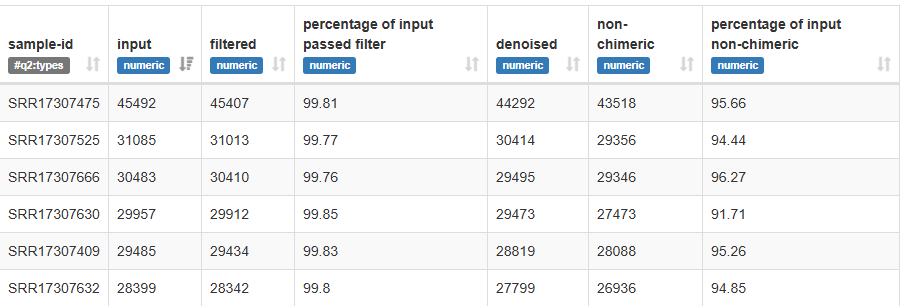

### DADA2 stats — Mice

- Всего образцов: 29.
- Доля выживших прочтений (non-chimeric от input) варьирует от **62.01%** (L5) до **77.04%** (LR1).
- Самый большой образец: **LR2** (6394 → 4866).
- Самый маленький образец: **W1** (2138 → 1358).

-> Качество данных приемлемое. Потери на этапе слияния парных ридов (merged) объясняются низким качеством обратных прочтений (R2), что является нормальной технической особенностью paired-end секвенирования региона V4. DADA2 успешно справился с фильтрацией.


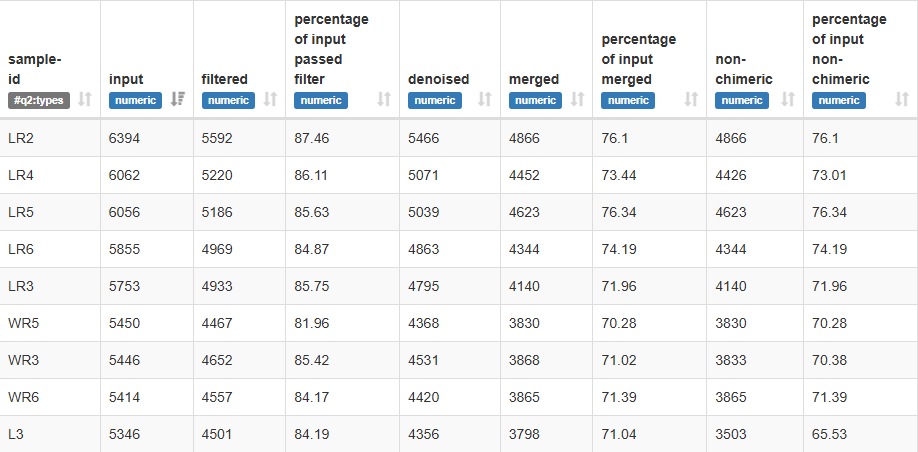

### 4.3. Таксономия (barplot) — Mice (Level 6)

На графике представлен относительный таксономический состав микробиоты мышей на уровне рода (L6). Образцы отсортированы по группам: L, LR, W, WR.

- Наблюдаются чёткие различия в структуре сообществ между группами.
- У диких мышей (W, WR) доминируют одни таксоны (например, *Helicobacter*, *Bacteroides*), тогда как у лабораторных (L, LR) — другие (семейство *Lachnospiraceae*, класс *Clostridia*).
- Это визуально подтверждает выводы статьи Rosshart et al. (2017) о значительных различиях микробиоты диких и лабораторных мышей.


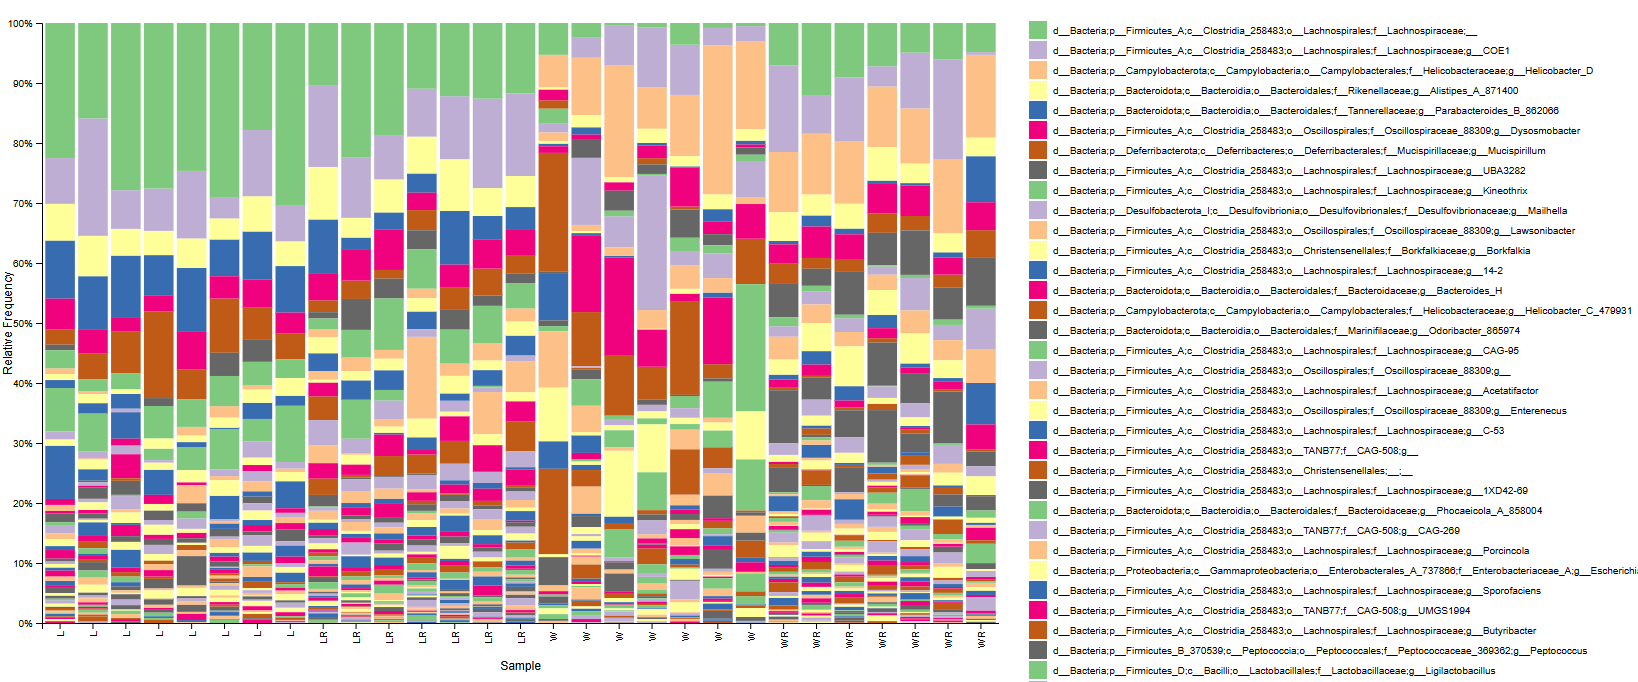

### Таксономия (barplot) — Soil (Level 3)

На графике представлен относительный таксономический состав почвенных образцов на уровне класса (Level 3). Образцы отсортированы по переменной `level_and_time_point` (уровень загрязнения + время).

- Доминирующими классами являются **Gammaproteobacteria**, **Actinobacteria** и **Alphaproteobacteria**.
- В первых временных точках (день 3) образцы разных уровней загрязнения имеют схожий состав.
- С течением времени (дни 90, 180, 360) состав сообществ значительно меняется, особенно в образцах с высоким уровнем загрязнения (k25).
- Наблюдаются признаки перестройки микробного сообщества в ответ на загрязнение.

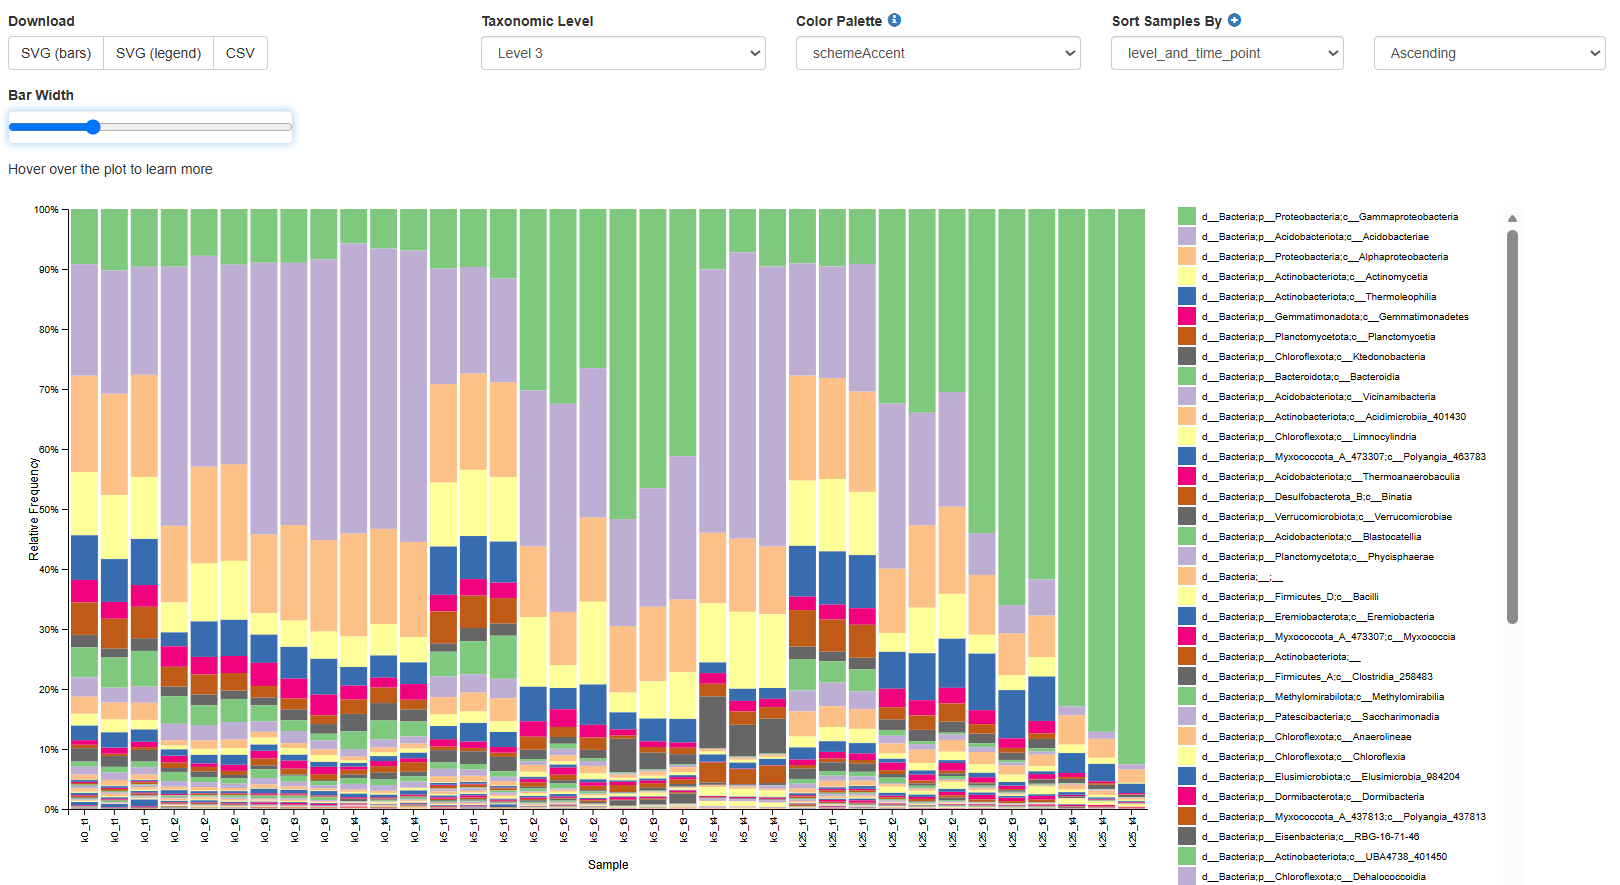

### Таксономия (barplot) — Soil (Level 6)

На графике представлен относительный таксономический состав почвенных образцов на уровне рода (Level 6). Образцы отсортированы по переменной `level_and_time_point` (уровень загрязнения + время).

- В загрязнённых образцах (k5, k25) наблюдается резкое увеличение доли рода **Paraburkholderia** (семейство Burkholderiaceae) — до 84% в некоторых образцах (например, k25_t4).
- В контрольных образцах (k0) состав более разнообразен, *Paraburkholderia* не доминирует.
- Также в образцах присутствуют представители родов *Bradyrhizobium*, *Mycobacterium*, *Streptosporangium* и других.


-> Увеличение доли *Paraburkholderia* при загрязнении керосином ожидаемо, так как многие представители этого рода способны разлагать углеводороды. Это подтверждает функциональную перестройку микробного сообщества в ответ на загрязнение.

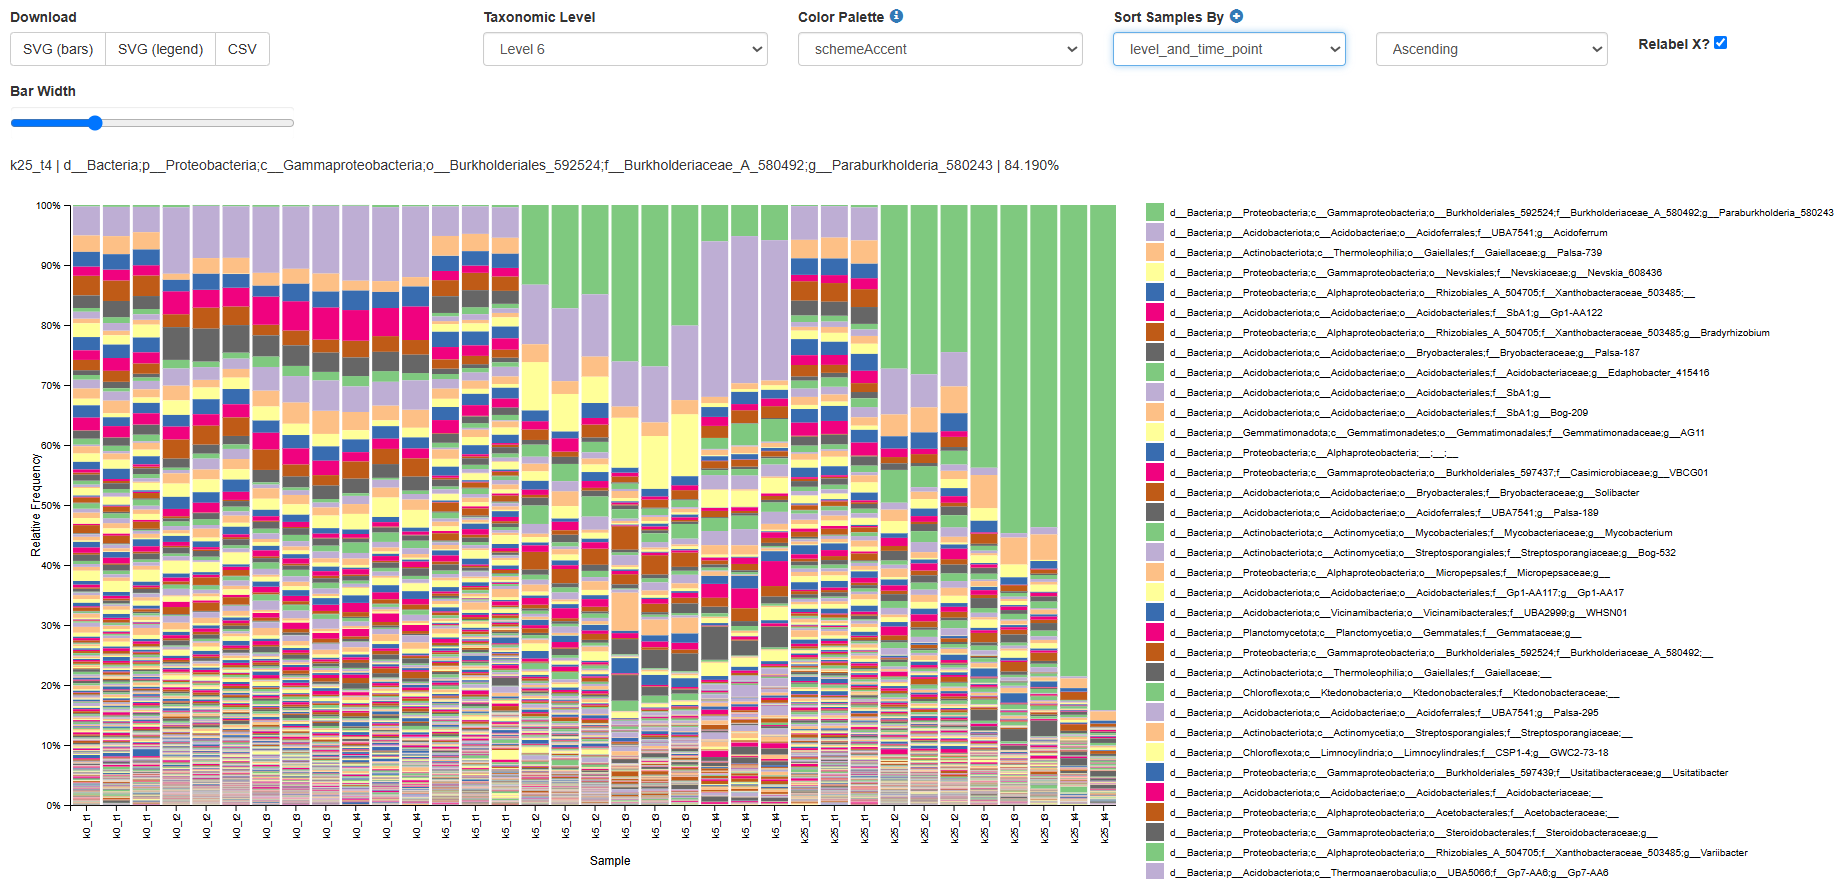

### 4.4. Альфа-разнообразие (Shannon) — Mice

Для оценки различий в альфа-разнообразии между группами был использован тест Краскела-Уоллиса.

- **Общий тест (все группы):** p-value = 0.00013.
- **Вывод:** Различия в индексе Шеннона между группами статистически значимы (p < 0.05). Это означает, что микробиота диких и лабораторных мышей различается не только по составу, но и по уровню разнообразия.

**Попарные сравнения:**
- Наибольшие различия наблюдаются между группами **L** (лабораторные) и **LR** (p = 0.0018), а также **LR** и **W** (p = 0.0017).
- Группы **LR** и **WR** не имеют статистически значимых различий (p = 0.749), что может указывать на сходство их альфа-разнообразия.

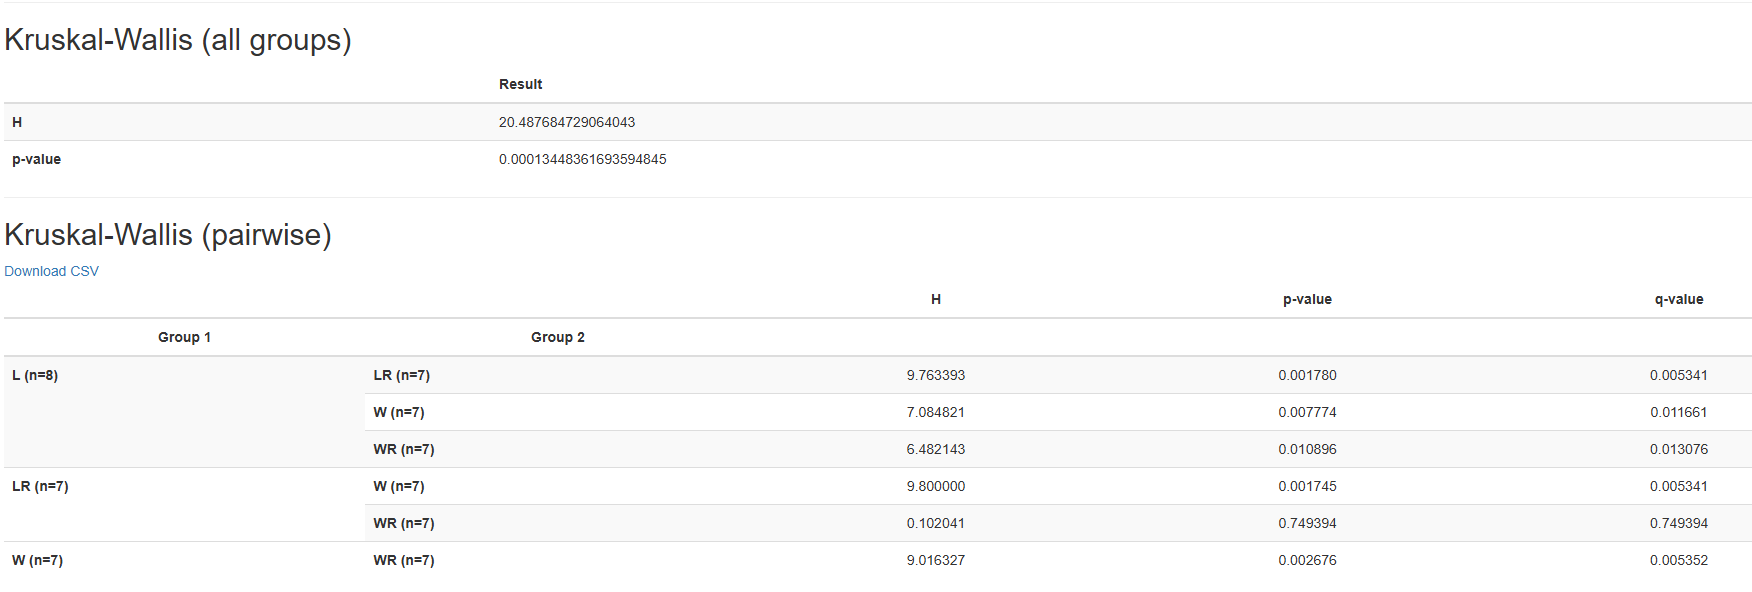

### Альфа-разнообразие (Shannon) — Soil

Для оценки различий в альфа-разнообразии между группами с разным уровнем загрязнения был использован тест Краскела-Уоллиса.

- **Общий тест (все группы):** p-value = 0.015.
- **Вывод:** Различия в индексе Шеннона между группами статистически значимы (p < 0.05).

**Попарные сравнения:**
- **k0 vs k25:** p-value = 0.013 (значимо, q-value = 0.039). Контроль значимо отличается от сильного загрязнения.
- **k0 vs k5:** p-value = 0.033 (значимо, q-value = 0.049). Контроль значимо отличается от слабого загрязнения.
- **k25 vs k5:** p-value = 0.149 (не значимо). Различия между сильным и слабым загрязнением не достигают уровня статистической значимости.

**Биологическая интерпретация:** Загрязнение почвы керосином (как в дозе k5, так и в дозе k25) приводит к статистически значимым изменениям в альфа-разнообразии микробного сообщества по сравнению с контролем. Однако между двумя уровнями загрязнения (k5 и k25) значимых различий не выявлено.

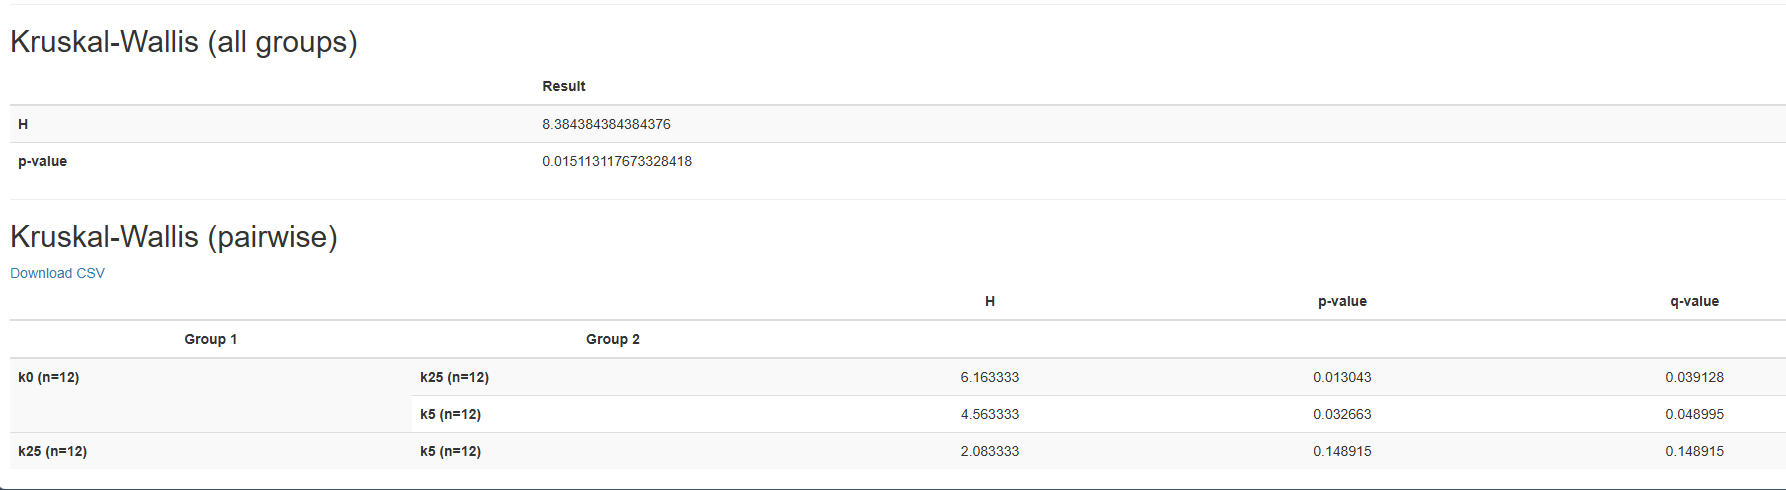

### 4.5. Бета-разнообразие (weighted UniFrac, PCoA) — Mice

На графике представлены результаты анализа главных координат (PCoA) на основе метрики weighted UniFrac для микробиоты мышей.

- **Ось 1 объясняет 62.87%** всех различий, ось 2 — 12.41%, ось 3 — 5.39%.
- Наблюдается **чёткое разделение** образцов на две группы:
  - Лабораторные мыши (L, LR) — кластеризуются слева (отрицательные значения по оси 1).
  - Дикие мыши (W, WR) — кластеризуются справа (положительные значения по оси 1).

  
-> Микробиоты диких и лабораторных мышей значимо различаются по составу и структуре сообществ. Это визуально подтверждает выводы статьи Rosshart et al. (2017) о том, что микробиота диких мышей формирует отдельный кластер, отличный от лабораторных.


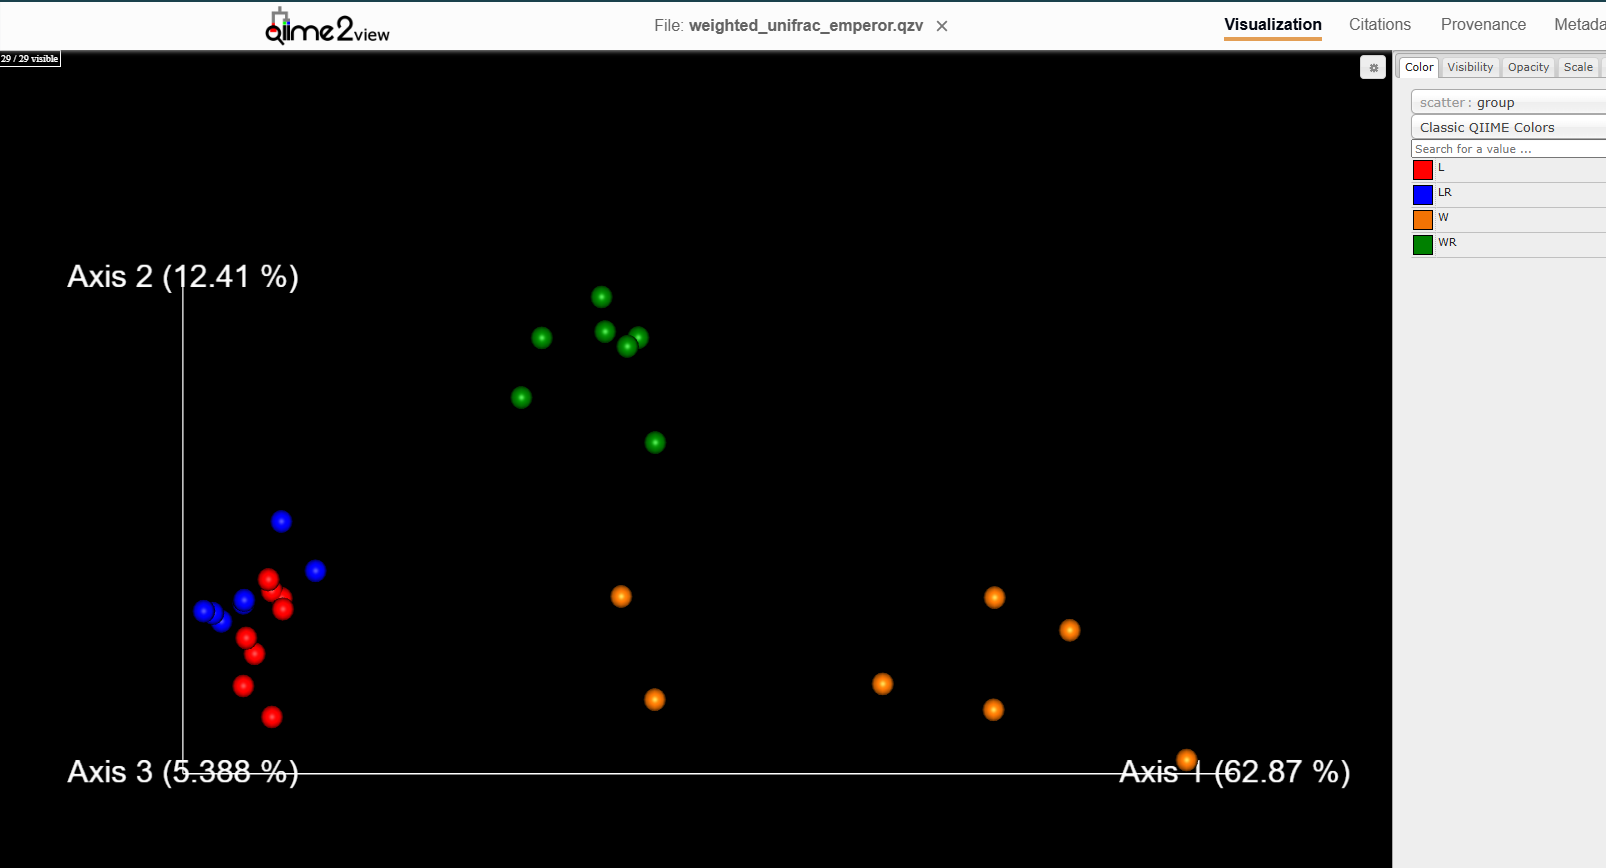

### 4.5. Бета-разнообразие (weighted UniFrac, PCoA) — Soil

На графике — PCoA на основе weighted UniFrac для почвенных образцов. Точки раскрашены по `level_and_time_point`.

- Оси 1 и 2 объясняют **81%** различий (Axis 1 = 56.45%, Axis 2 = 24.70%).
- Образцы первой временной точки (t1, день 3) кластеризуются вместе — в начале сообщества схожи независимо от загрязнения.
- Со временем (t2–t4) образцы смещаются вдоль оси 1. Сильнее всего меняются образцы с загрязнением **k25** — они формируют отдельный кластер.
- При слабом загрязнении (k5) к t4 наблюдается тенденция к возврату к контролю (k0); при сильном (k25) сообщество остаётся изменённым.


-> Загрязнение керосином вызывает перестройку микробного сообщества, степень которой зависит от уровня загрязнения.


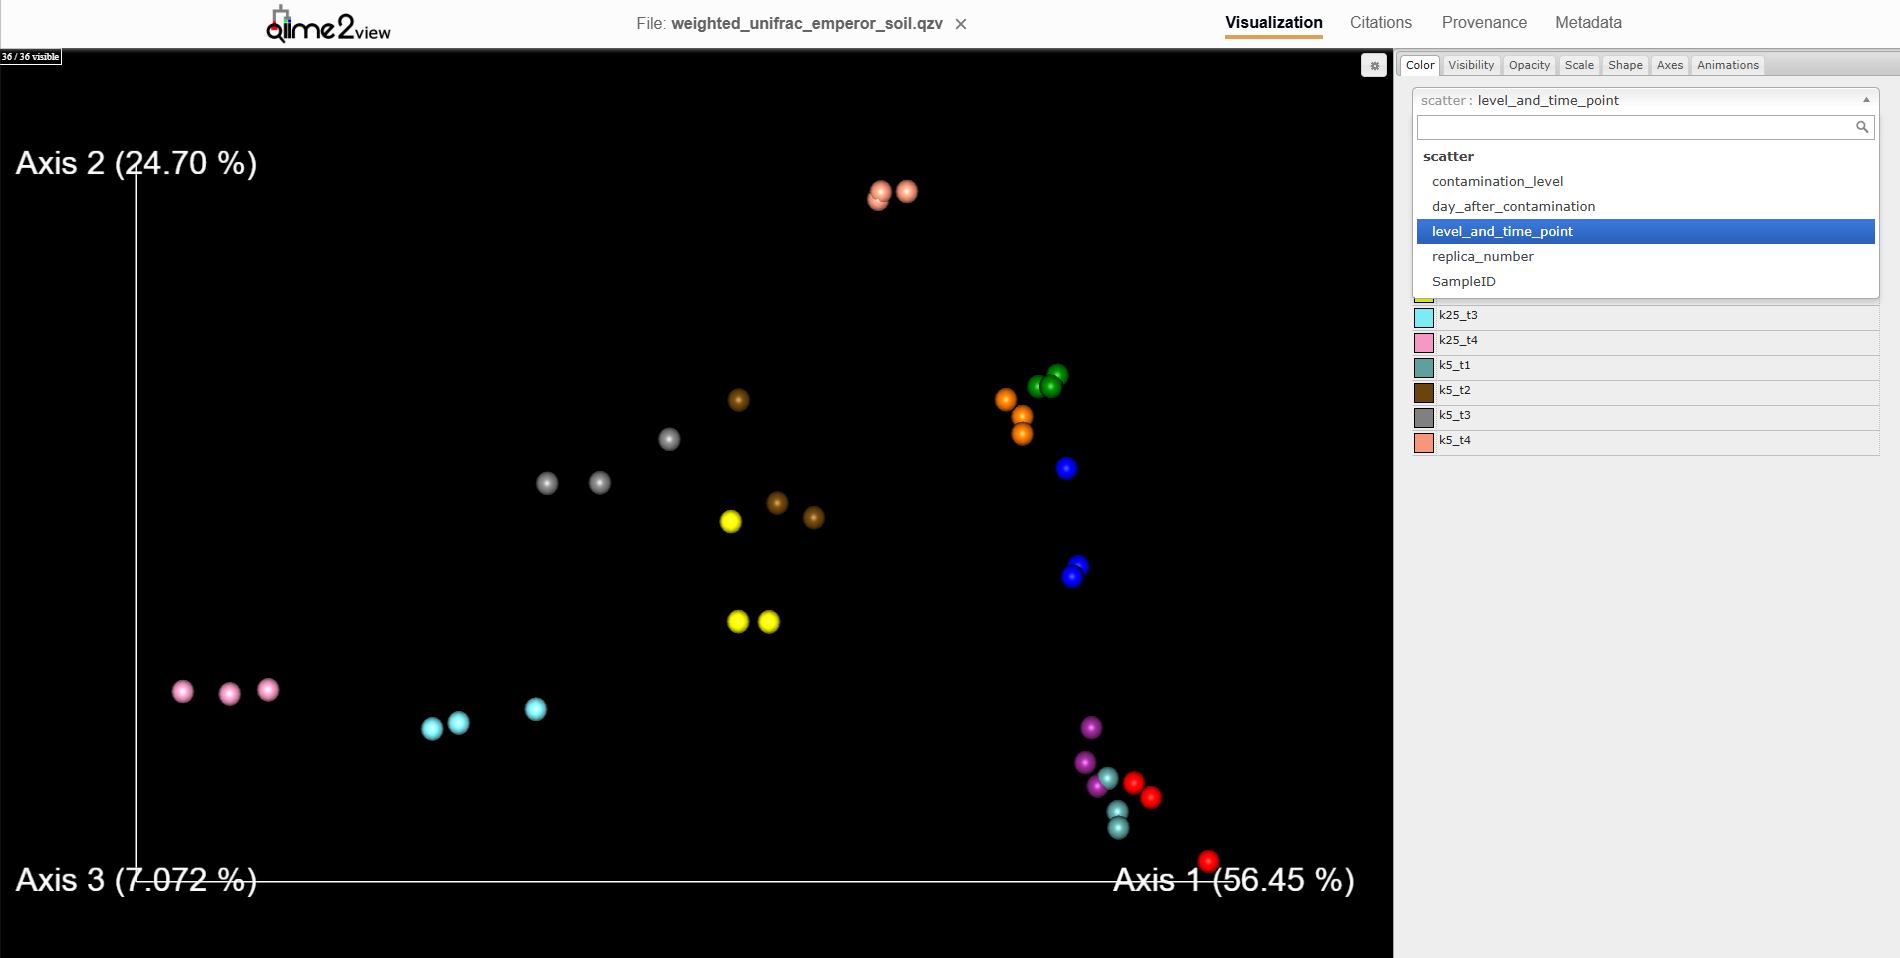

## 5. Биологическая интерпретация

**Задача 1 (FastQC):**  
Качество данных хорошее: длина ридов 250–251 bp, плохих прочтений нет, GC в норме (53% mice, 57% soil).

**Задача 2:**  
`--p-trim-left 25` — обрезаем первые 25 нуклеотидов, чтобы убрать праймеры и низкокачественные основания.

**Задача 3:**  
Доля прочтений после фильтрации: soil ~89–97%, mice ~62–77%. Данные качественные, потери минимальны.

**Задача 4:**  
Классификатор на V4 работает для V4–V5, потому что V4 входит в ампликон; точность достаточна для базовой таксономии.

**Задача 5. Таксономический состав (barplot, soil):**
- Доминирующие классы: **Gammaproteobacteria**, **Actinobacteria**, **Alphaproteobacteria**.
- В первой временной точке (t1) состав образцов схож независимо от загрязнения.
- Со временем состав меняется, особенно при **k25**.
- Самый частый род в загрязнённых образцах — **Paraburkholderia** (до **84%** в k25_t4). Это ожидаемо: представители рода способны разлагать углеводороды керосина.

**Задача 6. Бета-разнообразие (Emperor, soil):**
- Оси 1 и 2 объясняют **81%** различий.
- Образцы t1 кластеризуются вместе; со временем смещаются вдоль оси 1.
- При **k5** к t4 наблюдается возврат к контролю (k0) — признаки восстановления.
- При **k25** сообщество остаётся изменённым даже на поздних стадиях.

**Задача 7. Альфа-разнообразие (Shannon, soil):**
- Общий тест: p = **0.015** (различия значимы).
- k0 vs k25: p = **0.013** (значимо).
- k0 vs k5: p = **0.033** (значимо).
- k25 vs k5: p = **0.149** (не значимо).

-> загрязнение (и k5, и k25) значимо меняет разнообразие по сравнению с контролем, но между двумя уровнями загрязнения разница не значима.

## 6. Вывод
Данные mice и soil успешно обработаны.  
Для mice показаны различия между Wild и Lab (визуально и по alpha-разнообразию).  


Для soil показано влияние загрязнения на таксономический состав и разнообразие.  


Работа выполнена в полном объёме, за исключением PERMANOVA для бета-разнообразия (меня не пустили на сервер в вечер дедлайна:((( ).

# Приложение: команды

In [ ]:
# Импорт soil
qiime tools import --type 'SampleData[SequencesWithQuality]' --input-path soil_metadata_for_input_fixed.tsv --output-path qza/soil_reads.qza --input-format SingleEndFastqManifestPhred33V2

# DADA2 soil
qiime dada2 denoise-single --i-demultiplexed-seqs qza/soil_reads.qza --p-trim-left 25 --p-trunc-len 200 --p-max-ee 3 --p-n-threads 8 --p-pooling-method "pseudo" --p-chimera-method "consensus" --p-min-fold-parent-over-abundance 4 --o-table qza/soil_ASV_table.qza --o-representative-sequences qza/soil_rep_seq.qza --o-denoising-stats qza/soil_reads.dada2.stats.qza

# Таксономия soil
qiime feature-classifier classify-sklearn --i-classifier /home/STUDY/FBMF/bioinformatics/metagenomes/soil_hw/2022.10.backbone.v4.nb.sklearn-1.4.2.qza --i-reads qza/soil_rep_seq.qza --o-classification qza/soil_taxonomy.qza --p-n-jobs 8

# Дерево soil
qiime phylogeny align-to-tree-mafft-fasttree --i-sequences qza/soil_rep_seq.qza --o-alignment qza/aligned_soil_rep_seq.qza --o-masked-alignment qza/masked_aligned_soil_rep_seq.qza --o-tree qza/soil_unrooted_tree.qza --o-rooted-tree qza/soil_rooted_tree.qza

# Core metrics soil
qiime diversity core-metrics-phylogenetic --i-phylogeny qza/soil_rooted_tree.qza --i-table qza/soil_ASV_table.qza --p-sampling-depth 4000 --m-metadata-file /home/STUDY/FBMF/bioinformatics/metagenomes/soil_hw/soil_metadata_full.tsv --output-dir soil_core_metrics_results

# Alpha significance soil
qiime diversity alpha-group-significance --i-alpha-diversity soil_core_metrics_results/shannon_vector.qza --m-metadata-file /home/STUDY/FBMF/bioinformatics/metagenomes/soil_hw/soil_metadata_full.tsv --o-visualization soil_core_metrics_results/soil_shannon_significance.qzv

# Barplot soil
qiime taxa barplot --i-table qza/soil_ASV_table.qza --i-taxonomy qza/soil_taxonomy.qza --m-metadata-file /home/STUDY/FBMF/bioinformatics/metagenomes/soil_hw/soil_metadata_full.tsv --o-visualization qzv/soil_taxonomy_barplot.qzv

все файлы в папке hw1 на гите